Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. Никто вас не ограничивает в наведении красоты, но требуется выполнение того, что в задании.

Это задание немного отличается по структуре, тут нет конкретных заданий, вам нужно будет **ЗАПОЛНИТЬ ПРОПУСКИ** и сделать так, чтобы все работало. Ну и, конечно, написать **ВЫВОДЫ**!!!
***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import umap # umap-learn
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.datasets import load_wine
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score

# Введение

В этом домашнем задании мы поработаем с алгоритмами **понижения размерности данных**.  
Почему это вообще нужно и важно?

Во-первых, это немного похоже (и правда используется) на **кластеризацию**. В прошлой домашке вы поработали с регрессией и классификацией, а в этой пришло время и для «кластеризации».

Во-вторых, вообще говоря основная причина, такие алгоритмы помогают выделять значимые фичи в случае, когда **размерность данных (очень) большая**.

_**Пару слов про большую размерность и данные**_

Что вообще такое большая размерность? Это ситуация, когда количество признаков $D$ сравнимо с количеством объектов $n$ или даже превышает его. Например:
* изображение $28 \times 28$ пикселей = **784 признака**;
* текстовые данные после векторизации = **тысячи признаков**;
* генетические данные = **десятки тысяч признаков**.

Заметили, что речи про табличные данные не идет? Это не означает, что такие данные не страдают от «проклятия размерности» (кстати, когда такое может быть?), просто очевидные для человека проблемы не так видны.

_**Проблемы большой размерности:**_

| Проблема | Значение |
|----------|----------|
| **Вычислительная сложность** | Многие алгоритмы масштабируются как $O(D^2)$ или $O(D^3)$ |
| **Проклятие размерности** | В высоких размерностях все точки становятся «одинаково далеко» друг от друга |
| **Переобучение** | Модель запоминает шум вместо закономерностей |
| **Интерпретируемость** | Человеку сложно анализировать пространства с $D > 3$ |

_**Что дают методы снижения размерности:**_

1. **сжатие данных** — хранение и обработка становятся быстрее,
2. **визуализация** — возможность увидеть данные в 2D/3D,
3. **удаление шума** — отбрасываем компоненты с малой дисперсией,
4. **улучшение качества** — иногда классификаторы работают лучше на сниженных данных.

То есть можно выделить _**две основных цели**_ использования таких методов:
* **визуализация** данных для возможности интерпретации человеческим взглядом,
* **выделение фичей** для регрессии и классификации или прямое решение задачи **кластеризации**.

> В этой домашке будет два задания, вы поработаете на обе цели и сравните разные методы.

***
Теперь немного отдельно про каждый алгоритм. Мы не будем говорить про все возможные методы, поговорим про основные.

### PCA (Principal Component Analysis)

Кратенько и на русском [про PCA](https://habr.com/ru/articles/799001/)

Основная идея: найти такое **линейное подпространство меньшей размерности**, в которое можно спроецировать данные с минимальной потерей информации.

Пусть $X \in \mathbb{R}^{n \times D}$ — матрица данных с $n$ объектами и $D$ признаками.
Мы ищем проекцию $Y \in \mathbb{R}^{n \times d}$, где $d < D$, такую что:

$$
Y = XW, \quad W \in \mathbb{R}^{D \times d}
$$

где столбцы матрицы $W$ — ортонормированные векторы (главные компоненты).

PCA **максимизирует дисперсию** спроецированных данных:

$$
\max_{W: W^TW = I} \text{Tr}(W^T \Sigma W)
$$

где $\Sigma = \frac{1}{n}X^TX$ — ковариационная матрица (для центрированных данных).

Решение: столбцы $W$ — **собственные векторы** $\Sigma$, соответствующие 
наибольшим собственным значениям $\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_D$.

> Если первые 30 компонент объясняют 85% дисперсии, значит мы сохранили 85% "информации" исходных данных при сжатии в 30 раз.

То есть это некоторый **алгоритм обучения без учителя**!

### t-SNE (t-distributed Stochastic Neighbor Embedding)

Это тоже алгоритм машинного обучения, на русском про него [тут](https://habr.com/ru/articles/267041/)

Основная идея: **нелинейное снижение размерности** с сохранением локальной структуры данных — близкие точки в исходном пространстве остаются близкими.

_**Алгоритм очень простыми словами**_

1. **В исходном пространстве** ($\mathbb{R}^D$):
   - Для каждой пары точек $(i, j)$ вычисляем условную вероятность:
   $$
   p_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)}
   $$
   - Симметризуем: $p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$

2. **В пространстве низкой размерности** ($\mathbb{R}^d$, обычно $d=2$):
   - Используем t-распределение Стьюдента с 1 степенью свободы:
   $$
   q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq l}(1 + ||y_k - y_l||^2)^{-1}}
   $$

3. **Оптимизация**: минимизируем расхождение Кульбака-Лейблера:
   $$
   KL(P||Q) = \sum_{i \neq j} p_{ij} \log\frac{p_{ij}}{q_{ij}}
   $$
   с помощью градиентного спуска.

_**Гиперпараметры:**_

| Параметр | Описание |  |
|----------|----------|------------------|
| `n_components` | Размерность выхода | 2, 3 |
| `perplexity` | Баланс локальной/глобальной структуры | 5–50 |
| `learning_rate` | Шаг градиентного спуска | 10–1000 |
| `n_iter` | Число итераций оптимизации | ≥ 250 |

> t-SNE не сохраняет глобальные расстояния и масштабы кластеров! Интерпретируйте только относительную близость точек.

### UMAP (Uniform Manifold Approximation and Projection)

Про все и [про Umap](https://habr.com/ru/companies/newprolab/articles/350584/) тоже

Основная идея: аппроксимация многообразия данных с **сохранением как локальной, 
так и глобальной** структуры.

1. Предполагается, что данные равномерно распределены на римановом многообразии
2. Строится взвешенный граф соседства в исходном пространстве
3. Оптимизируется расположение точек в низкой размерности для сохранения структуры графа

```python
umap.UMAP(
    n_components=2,      # целевая размерность
    n_neighbors=15,      # размер локального окружения (аналог perplexity)
    min_dist=0.1,        # минимальное расстояние между точками в эмбеддинге
    metric='euclidean',  # метрика расстояния
    random_state=42
)
```

***

Ну чтож, давайте делать! Реализовывать ничего не надо будет, надо будет _применять_ и _интерпретировать_.

# Задание 1: большая и страшная размерность (6 pt)

### Данные

Для этого задания мы с вами возьмем новый для нас вид данных (в предверии следующей темы) — **картиночки**!

Будем использовать классический датасет `MNIST` с изображениями десяти цифр (10 классов). Каждая картинка как и в примере — это $28 \times 28$ пикселей = **784 признака**. 

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"]

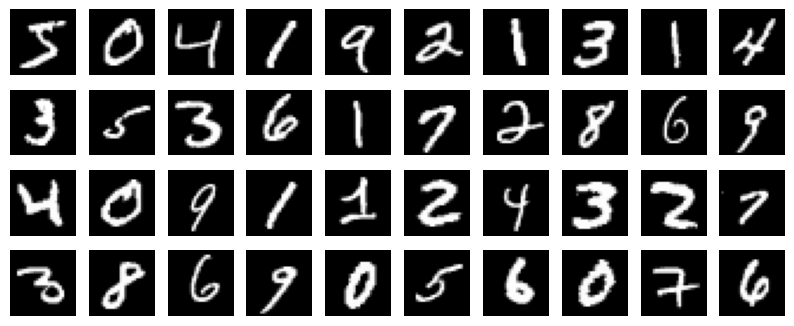

In [3]:
plt.figure(figsize=(10, 4))
for i in range(40):
    plt.subplot(4, 10, i + 1)
    plt.imshow(np.array(X[i]).reshape((28, 28)), cmap='gray')
    plt.axis('off')

Разделим наше все на обучающую и тестовую выборки

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(56000, 784)
(14000, 784)


### Применение алгоритмов (3 pt)

Давайте теперь попробуем **понизить размерность в... 15 раз**!

На train выборке постройте **проекцию на 50 главных компонент**. Какую **долю дисперсии** данных они объясняют? Какую долю дисперсии объясняет **каждая компонента по отдельности**?

In [ ]:
pca = ...
X_train_pca = pca.fit_transform(X_train)

In [ ]:
# посмотрите как сожмутся изображения по каждой из компонент

plt.figure(figsize=(12, 4))    
for i in range(30):
    plt.subplot(3, 10, i + 1)
    plt.imshow(pca.components_[i].reshape((28, 28)), cmap='gray')
    plt.axis('off')

In [ ]:
# ответ на вопрос какую долю дисперсии объясняют компоненты
raise NotImplementedError

In [ ]:
# ответ на вопрос какую дисперсию объясняет каждая из компонент
raise NotImplementedError

In [ ]:
# предыдущий пункт в наглядном виде графика
raise NotImplementedError

**ВАШ ВЫВОД** про объяснение дисперсии и оптимальную размерность

...

Теперь **визуализируйте главные компоненты**. Легко ли они интерпретируются/разделяют данные?

In [ ]:
y_numeric_train = y_train.astype(int)
mnist_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

plt.figure(figsize=(15, 15))
scat = plt.scatter(...)
plt.legend(...)
...

plt.show()

**ВАШ ВЫВОД** про разделимость

...

Теперь давайте еще визуализируем данные при помощи **t-SNE** и **UMAP**.

Но для начала поймем, на каких данных эти алгоритмы применять. _Что лучше использовать на исходных признаках (значениях пикселей), а что на главных $n$ компонентах?_

**ВАШ ОТВЕТ:**

...

In [ ]:
# используем t-SNE для ...?

tsne = ...
X_train_tsne = tsne.fit_transform(X_train_pca)

plt.figure(figsize=(15, 15))
scat = ...
...

plt.show()

In [ ]:
# используем UMAP для ...?

umap_ = ...
X_train_umap = umap_.fit_transform(X_train)

plt.figure(figsize=(15, 15))
scat = ...
...

plt.show()

In [ ]:
# может вы захотите еще что-то проверить
...

**ВАШ ВЫВОД** по применению методов и объяснению, почему оно так получается

...

### Обучение модели (3 pt)

Давайте теперь попробуем использовать полученные ранее результаты для **обучения классификатора**. Будем использовать максимально простой — логистическую регрессию.

Нужно:
1. обучить модель для каждого метода,
2. оценить качество при помощи `accuracy`, `recall` и `f1`.

In [ ]:
# сохраним значения для сравнения

metrics = {
    'pca' : {
        'accuracy' : 0,
        'recall' : 0,
        'f1' : 0
    },
    't-sne' : {
        'accuracy' : 0,
        'recall' : 0,
        'f1' : 0
    },
    'umap' : {
        'accuracy' : 0,
        'recall' : 0,
        'f1' : 0
    }
}

y_numeric_train = y_train.astype(int)
y_numeric_test = y_test.astype(int)

In [ ]:
# обучаем после pca

model_pca = ...
...

X_test_pca = pca.transform(...)

predicted_pca = model_pca.predict(...)

metrics['pca']['accuracy'] = accuracy_score(...)
metrics['pca']['recall'] = recall_score(..., ..., average='weighted')
metrics['pca']['f1'] = f1_score(..., ..., average='weighted')

print(f"accuracy = {metrics['pca']['accuracy']}")
print(f"recall = {metrics['pca']['recall']}")
print(f"F1-score = {metrics['pca']['f1']}")

In [ ]:
# обучаем после t-sne
# t-sne не сохраняет данные для изменения, надо заного учить его на тесте

model_tsne = .
...

X_test_tsne = tsne.fit_transform(...)

predicted_tsne = model_tsne.predict(...)

metrics['t-sne']['accuracy'] = ...
metrics['t-sne']['recall'] = ...
metrics['t-sne']['f1'] = ...

print(f"accuracy = {metrics['t-sne']['accuracy']}")
print(f"recall = {metrics['t-sne']['recall']}")
print(f"F1-score = {metrics['t-sne']['f1']}")

In [ ]:
# обучаем после umap

model_umap = ...
...

X_test_umap = umap_.transform(...)

predicted_umap = model_umap.predict(...)

metrics['umap']['accuracy'] = ...
metrics['umap']['recall'] = ...
metrics['umap']['f1'] = ...

print(f"accuracy = {metrics['umap']['accuracy']}")
print(f"recall = {metrics['umap']['recall']}")
print(f"F1-score = {metrics['umap']['f1']}")

**ВАШИ ВЫВОДЫ** про обучение и сам подход к изменению признаков

...

# Задание 2: понижение для фичей (4 pt)

В этом задании снова поработаем с классификацией, но уже с **табличными данными**.

Будем использовать простельний датасет для классивикации вин (я не виновата, что хорошие датасеты такие..., что нашла, то нашла).

### Данные (1 pt)

In [5]:
data = load_wine()
X, y = data['data'], data['target']
X.shape

(178, 13)

Датасет маленький, видно, что от проклятия размерности мы тут не страдаем.

In [ ]:
print(data['DESCR'])

Делим на test и train, **поделим практически поровну**, иммитируя маленькое количество данных, и чтобы было, на чем сверяться.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)

(106, 13)
(72, 13)


Сначала сделаем **стандартизацию данных**. Объясните, почему она тут нужна.

_Посмотрите на данные (оставьте только 2-3 нужных графика!)_

In [ ]:
# тут код для ответа на вопрос про зачем нужна

raise NotImplementedError

**ТЕКСТОВЫЙ ОТВЕТ** на вопрос про то, зачем стандартизировать

...

In [ ]:
# стандартизируем данные

...
X_train = ...
X_test = ...

### Понижение размерности (1 pt)

Теперь давайте визуализируем **проекцию** выборки на первые **две главные компоненты**.

_Как мы это делаем? Разделимы ли классы линейно?_

In [ ]:
# что-то применяем

raise NotImplementedError

In [ ]:
# визуализируем

plt.figure(figsize=(15, 15))
scat = ...

...

plt.show()

**ВАШ ТЕКСТОВЫЙ ОТВЕТ** на вопрос про то, как делаем и про разделимость

...

### Обучение модели (2 pt)

Просто обучать уже умеем, тут сделаем чуть более интересную вещь.

Постройте **график зависимоти качества модели** (все так же логистическая регрессия) **от числа компонент**. _Есть какие-то зависимости?_

In [ ]:
# учим и запоминаем

model = LogisticRegression()

f1 = []

for i in range(1, 14):

    raise NotImplementedError

    f1.append(...)

In [ ]:
# визуализируем

...

plt.show()

**ВАШ ТЕКСТОВЫЙ ОТВЕТ** на вопрос про зависимости

...

***
Давайте теперь воспользуемся знаниями из прошлого дз и обучим `Lasso` регрессию (с L1 регуляризацией), чтобы **выделить важные признаки**. Кстати сделаем мы это немного по-другому.

_В чем отличие такого подхода от pca?_

In [ ]:
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=1000)
lasso.fit(X_train, y_train)

Но ведь регрессия может давать бинарный ответ «да/нет», как быть с тем, что **у нас 3 класса**?

In [ ]:
# это поможет понять ответ

lasso.coef_

**ВАШ ТЕКСТОВЫЙ ОТВЕТ** на вопрос про то, как же быть с многоклассовой классификацией

...

In [ ]:
# визуализируем важность всех фич (коэффициенты) для каждого класса

plt.figure(figsize=(14, 10))
plt.bar(..., ..., ...)
plt.bar(..., ..., ...)
plt.bar(..., ..., ...)
...

plt.legend()
plt.show()

**ВАШ ВЫВОД И ТЕКСТОВЫЙ ОТВЕТ** об отличии от pca

...

**ИТОГОВЫЙ ВОПРОС**

Так в итоге что и когда лучше применять, как это использовать и интерпретировать?

**ВАШ ИТОГОВЫЙ ОТВЕТ**

...

***
Ура, все  
P.S. веселое настроение было пока делала